<a href="https://colab.research.google.com/github/SanjaraT/Attention-Based-Multi-Scale-Ensemble-Network-for-Diabetic-Retinopathy-Detection/blob/main/DR_Attention_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sanjara9933","key":"8985c3f5225989948db98acc2fb01820"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d sovitrath/diabetic-retinopathy-224x224-gaussian-filtered

Dataset URL: https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered
License(s): CC0-1.0
100% 427M/427M [00:06<00:00, 71.7MB/s]



In [6]:
!unzip -q diabetic-retinopathy-224x224-gaussian-filtered.zip

In [10]:
import os

dataset_path = "/content/gaussian_filtered_images/gaussian_filtered_images"

print(os.listdir(dataset_path))

['Moderate', 'export.pkl', 'Proliferate_DR', 'Severe', 'Mild', 'No_DR']


In [11]:
total_images = 0

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total_images += count

        print(f"{cls}: {count}")

print("\nTotal Images:", total_images)

Moderate: 999
Proliferate_DR: 295
Severe: 193
Mild: 370
No_DR: 1805

Total Images: 3662


# Data Frame

In [12]:
import os
import pandas as pd

image_paths = []
labels = []

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):

        image_paths.append(
            os.path.join(class_path, img_name)
        )

        labels.append(class_name)

df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print(df.shape)

df.head()

(3662, 2)


,filepath,label
0,/content/gaussian_filtered_images/gaussian_fil...,Moderate
1,/content/gaussian_filtered_images/gaussian_fil...,Moderate
2,/content/gaussian_filtered_images/gaussian_fil...,Moderate
3,/content/gaussian_filtered_images/gaussian_fil...,Moderate
4,/content/gaussian_filtered_images/gaussian_fil...,Moderate


In [13]:
print(df.isnull().sum())

filepath    0
label       0
dtype: int64


# Class Distribution Plot

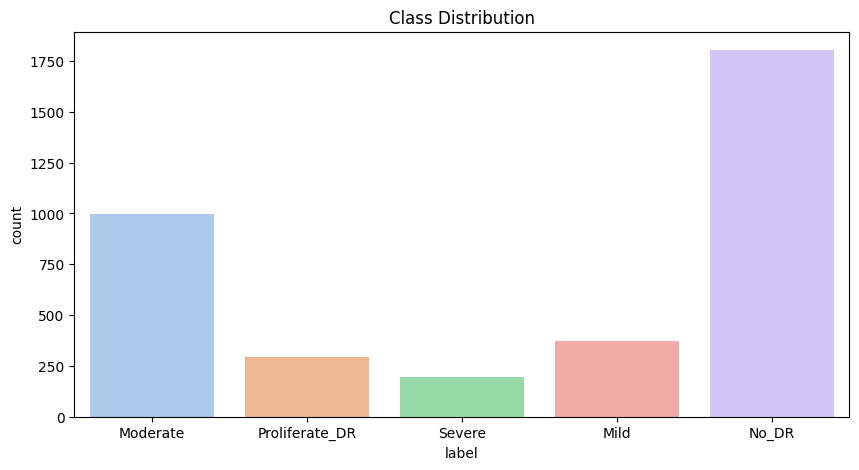

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='label',
    palette='pastel',
    hue='label',
    legend=False
)

plt.title("Class Distribution")
plt.show()

# Sample Images

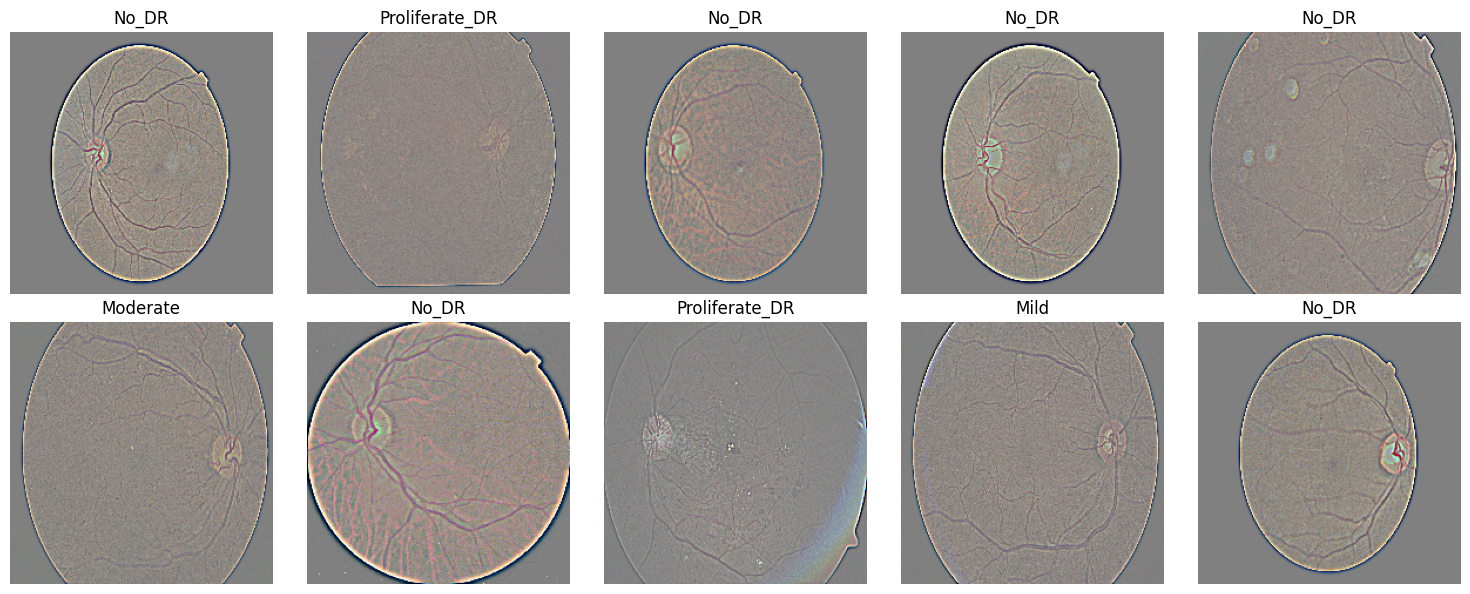

In [17]:
import cv2
import random

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

for ax in axes.flat:

    idx = random.randint(0, len(df)-1)

    img = cv2.imread(
        df.iloc[idx]["filepath"]
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(img)

    ax.set_title(
        df.iloc[idx]["label"]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2563
Validation: 549
Test: 550


# Compute Class Weights

In [19]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    i: weight
    for i, weight in enumerate(weights)
}

print(class_weights)

{0: np.float64(1.9791505791505792), 1: np.float64(0.7333333333333333), 2: np.float64(0.4058590657165479), 3: np.float64(2.476328502415459), 4: np.float64(3.797037037037037)}


# Parameters

In [20]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Data Augmentation

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.1,
    height_shift_range=0.1,

    zoom_range=0.15,

    horizontal_flip=True,

    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

# Generators

In [22]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = valid_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = valid_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2563 validated image filenames belonging to 5 classes.
Found 549 validated image filenames belonging to 5 classes.
Found 550 validated image filenames belonging to 5 classes.


In [23]:
# class mapping
print(train_generator.class_indices)

{'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}
